In [ ]:
from google.colab import files
uploaded = files.upload()


# DATA VORTEX — Round 1 Phase 1
## Social Engine Data Intake Restoration

### Objective
Restore the corrupted Social Engine dataset by:
- Auditing data quality
- Handling missing values
- Removing duplicate records
- Correcting corrupted/inconsistent data
- Identifying anomalies
- Standardizing data formats
- Validating the cleaned dataset
- Performing exploratory data analysis
- Generating meaningful insights

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import html

from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 100)

In [2]:
users = pd.read_csv(
    "data/Social_Engine_Users.csv"
)

posts = pd.read_csv(
    "data/Social_Engine_Posts_Corrupted.csv"
)

In [3]:
print("Users:", users.shape)
print("Posts:", posts.shape)

Users: (1500, 5)
Posts: (12360, 8)


In [4]:
users.head()


,user_id,location,language,account_created,follower_count
0,user_guglt5jp,"Berlin, Germany",ja,2023-10-23,38963
1,user_b1p3wz81,"Munich, Germany",zh,2023-05-06,24644
2,user_jm2grmis,"Dubai, UAE",en,2023-01-03,45842
3,user_ykoqww5l,"Paris, France",fr,2023-10-11,665
4,user_3zzvv8vp,"Los Angeles, USA",ru,2023-05-23,42908


In [5]:
posts.head()

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
0,to64mgey2v3y,user_vfxs1pry,Reddit,Bummed out with my new Air Max from Nike! Abso...,25-09-2024,4488.0,1456,673
1,7f0wdauzbj89,user_8l7rv5oe,Reddit,My one month review of Pepsi Crystal Pepsi: Hi...,1722528840,789.0,1484,39
2,dvvhg8eel45x,user_nfo3ih5u,NaN,Just unboxed my new Highlander from Toyota. Ex...,2025-04-13T20:12:18,NaN,1410,839
3,hgb9cxke4t7b,user_27aje6ur,Facebook,Comparing Pepsi Crystal Pepsi to the competiti...,10-09-2024,167.0,584,833
4,zwerpw3wk320,user_9px5q0by,Reddit,My one week review of Coca-Cola Diet Coke: Bes...,31-05-2024,4749.0,152,630


In [6]:
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          1500 non-null   object
 1   location         1500 non-null   object
 2   language         1500 non-null   object
 3   account_created  1500 non-null   object
 4   follower_count   1500 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 58.7+ KB


In [7]:
posts.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12360 entries, 0 to 12359
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   post_id       12360 non-null  object 
 1   user_id       12360 non-null  object 
 2   platform      10514 non-null  object 
 3   text_content  10614 non-null  object 
 4   timestamp     12360 non-null  object 
 5   likes         10502 non-null  float64
 6   shares        12360 non-null  int64  
 7   comments      12360 non-null  int64  
dtypes: float64(1), int64(2), object(5)
memory usage: 772.6+ KB


In [8]:
users.describe(include="all")

,user_id,location,language,account_created,follower_count
count,1500,1500,1500,1500,1500.000000
unique,1500,33,10,359,NaN
top,user_057ka83m,"Shanghai, China",zh,2023-06-04,NaN
freq,1,56,168,11,NaN
mean,NaN,NaN,NaN,NaN,24964.019333
std,NaN,NaN,NaN,NaN,14185.477457
min,NaN,NaN,NaN,NaN,109.000000
25%,NaN,NaN,NaN,NaN,12771.750000
50%,NaN,NaN,NaN,NaN,24741.500000
75%,NaN,NaN,NaN,NaN,37097.250000


In [9]:
posts.describe(include="all")

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
count,12360,12360,10514,10614,12360,10502.000000,12360.000000,12360.000000
unique,12000,1500,5,10225,8839,NaN,NaN,NaN
top,utkzs6e0k0pe,user_zqv2vrf5,YouTube,NULL\n\n,30-05-2024,NaN,NaN,NaN
freq,3,22,2136,24,21,NaN,NaN,NaN
mean,NaN,NaN,NaN,NaN,NaN,2247.075795,1005.867557,504.081958
std,NaN,NaN,NaN,NaN,NaN,1797.342958,574.734542,288.796752
min,NaN,NaN,NaN,NaN,NaN,-4987.000000,0.000000,0.000000
25%,NaN,NaN,NaN,NaN,NaN,1038.250000,509.000000,252.000000
50%,NaN,NaN,NaN,NaN,NaN,2387.000000,1016.000000,503.000000
75%,NaN,NaN,NaN,NaN,NaN,3664.000000,1499.000000,755.000000


In [10]:
def quality_report(df):
    report = pd.DataFrame({
        "column": df.columns,
        "dtype": df.dtypes.astype(str),
        "missing_count": df.isna().sum().values,
        "missing_percent": (df.isna().mean() * 100).round(2).values,
        "unique_values": df.nunique(dropna=False).values
    })

    return report


users_quality = quality_report(users)
posts_quality = quality_report(posts)

users_quality

,column,dtype,missing_count,missing_percent,unique_values
user_id,user_id,object,0,0.0,1500
location,location,object,0,0.0,33
language,language,object,0,0.0,10
account_created,account_created,object,0,0.0,359
follower_count,follower_count,int64,0,0.0,1481


In [11]:
posts_quality

,column,dtype,missing_count,missing_percent,unique_values
post_id,post_id,object,0,0.00,12000
user_id,user_id,object,0,0.00,1500
platform,platform,object,1846,14.94,6
text_content,text_content,object,1746,14.13,10226
timestamp,timestamp,object,0,0.00,8839
likes,likes,float64,1858,15.03,4753
shares,shares,int64,0,0.00,1994
comments,comments,int64,0,0.00,1001


In [12]:
print(
    "Duplicate complete rows:",
    posts.duplicated().sum()
)

Duplicate complete rows: 360


In [13]:
print(
    "Duplicate post IDs:",
    posts["post_id"].duplicated().sum()
)

Duplicate post IDs: 360


In [14]:
duplicate_posts = posts[
    posts["post_id"].duplicated(keep=False)
].sort_values("post_id")

duplicate_posts.head(20)

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
10546,01jzjra6mmwc,user_bqp8mrav,YouTube,Comparing Toyota Corolla to the competition. N...,2024-10-13T15:19:29,2829.0,776,654
3003,01jzjra6mmwc,user_bqp8mrav,YouTube,Comparing Toyota Corolla to the competition. N...,2024-10-13T15:19:29,2829.0,776,654
6645,03gqkhd2ebdg,user_ysbkmmxf,Facebook,My two days review of Adidas Stan Smith: Worth...,2024-10-20T20:14:36,NaN,966,833
11348,03gqkhd2ebdg,user_ysbkmmxf,Facebook,My two days review of Adidas Stan Smith: Worth...,2024-10-20T20:14:36,NaN,966,833
4324,03qci0ig2dz1,user_oki4xfhu,Instagram,Nike WinterWonders is amazing! Can't wait to s...,2024-10-26T20:54:04,3506.0,379,449
5671,03qci0ig2dz1,user_oki4xfhu,Instagram,Nike WinterWonders is amazing! Can't wait to s...,2024-10-26T20:54:04,3506.0,379,449
3983,06h8cm4e5ouf,user_hq1akhdd,YouTube,Has anyone else experienced customer service w...,2025-03-31T02:18:50,NaN,1204,470
2633,06h8cm4e5ouf,user_hq1akhdd,YouTube,Has anyone else experienced customer service w...,2025-03-31T02:18:50,NaN,1204,470
4032,06rvkdi7ipfz,user_2te8mebn,YouTube,Should I upgrade about Pepsi's Pepsi Zero Suga...,2024-12-30T13:28:02,4950.0,325,953
9153,06rvkdi7ipfz,user_2te8mebn,YouTube,Should I upgrade about Pepsi's Pepsi Zero Suga...,2024-12-30T13:28:02,4950.0,325,953


In [15]:
duplicate_groups = (
    duplicate_posts
    .groupby("post_id")
    .nunique()
)

duplicate_groups.head()

,user_id,platform,text_content,timestamp,likes,shares,comments
post_id,,,,,,,
01jzjra6mmwc,1,1,1,1,1,1,1
03gqkhd2ebdg,1,1,1,1,0,1,1
03qci0ig2dz1,1,1,1,1,1,1,1
06h8cm4e5ouf,1,1,1,1,0,1,1
06rvkdi7ipfz,1,1,1,1,1,1,1


In [16]:
duplicate_groups.max()

,0
user_id,1
platform,1
text_content,1
timestamp,1
likes,1
shares,1
comments,1


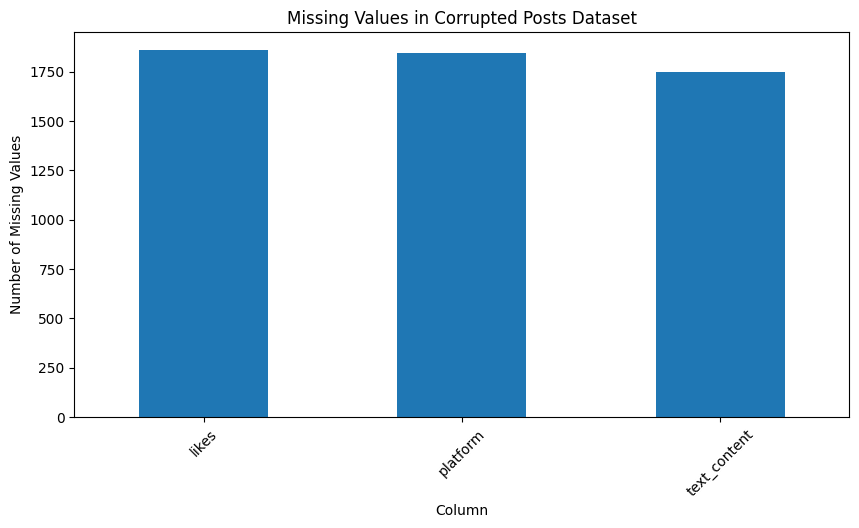

In [17]:
missing = posts.isna().sum()

missing = missing[missing > 0].sort_values(ascending=False)

plt.figure(figsize=(10, 5))

missing.plot(kind="bar")

plt.title("Missing Values in Corrupted Posts Dataset")
plt.xlabel("Column")
plt.ylabel("Number of Missing Values")
plt.xticks(rotation=45)

plt.show()

In [18]:
posts["platform"].value_counts(dropna=False)

,count
platform,
YouTube,2136
Facebook,2135
Twitter,2119
Reddit,2086
Instagram,2038
NaN,1846


In [19]:
posts["platform"] = posts["platform"].fillna("Unknown")

In [20]:
posts["text_content"].isna().sum()

np.int64(1746)

In [21]:
posts[
    posts["text_content"].isna()
].head()

,post_id,user_id,platform,text_content,timestamp,likes,shares,comments
15,k9tvoyfmg8az,user_kf84zwv2,Facebook,NaN,1740278648,4153.0,450,319
21,0eupqhh38ego,user_261d32en,Instagram,NaN,1742357104,2900.0,186,978
25,jhzjp26xujxh,user_lpaf67a1,YouTube,NaN,1715414900,3136.0,533,190
33,bm0zjjwqdjdt,user_wolyc68e,Twitter,NaN,2024-06-15T07:07:50,2712.0,1150,436
36,aq3dtllhs6dr,user_2a5282v7,YouTube,NaN,04-10-2024,NaN,197,21


In [22]:
null_text = posts[
    posts["text_content"]
    .fillna("")
    .str.strip()
    .eq("NULL")
]

print(len(null_text))

24


In [23]:
posts["text_content"] = posts["text_content"].replace(
    "NULL",
    np.nan
)

In [24]:
html_tag_mask = (
    posts["text_content"]
    .fillna("")
    .str.contains(r"<[^>]+>", regex=True)
)

print("HTML-corrupted records:", html_tag_mask.sum())

HTML-corrupted records: 663


In [25]:
posts.loc[
    html_tag_mask,
    "text_content"
].head(10)

,text_content
48,Just tried the Superstar from Adidas. Wouldn't...
65,Just saw an ad for Samsung Neo QLED TV during ...
92,Just unboxed my new Epic React from Nike. Exce...
102,Comparing Google Pixel Watch to the competitio...
154,Just tried the Pixel Watch from Google. Highly...
195,Apple InnovationX is impressive! Can't wait to...
201,Just saw an ad for Apple Vision Pro during the...
205,Just saw an ad for Amazon Kindle during the In...
288,My one week review of Coca-Cola Diet Coke: Hig...
298,Just saw an ad for Microsoft Surface Pro durin...


In [26]:
entity_mask = (
    posts["text_content"]
    .fillna("")
    .str.contains(
        r"&[a-zA-Z]+;",
        regex=True
    )
)

print(
    "HTML entity corruption:",
    entity_mask.sum()
)

HTML entity corruption: 341


In [27]:
encoding_mask = (
    posts["text_content"]
    .fillna("")
    .str.contains("Ã", regex=False)
)

print(
    "Encoding-corrupted records:",
    encoding_mask.sum()
)

Encoding-corrupted records: 316


In [28]:
def clean_text(text):
    if pd.isna(text):
        return "[MISSING_TEXT]"

    text = str(text).strip()

    # Remove HTML tags
    text = re.sub(
        r"<[^>]+>",
        "",
        text
    )

    # Decode HTML entities
    text = html.unescape(text)

    # Repair observed UTF-8 mojibake
    if "Ã" in text:
        try:
            text = text.encode("latin1").decode("utf-8")
        except (UnicodeEncodeError, UnicodeDecodeError):
            pass

    # Treat literal NULL / empty text as missing
    if text.upper() == "NULL" or text.strip() == "":
        return "[MISSING_TEXT]"

    return text.strip()

In [29]:
posts["text_content"] = (
    posts["text_content"]
    .apply(clean_text)
)

In [30]:
posts["text_content"].head(10)

,text_content
0,Bummed out with my new Air Max from Nike! Abso...
1,My one month review of Pepsi Crystal Pepsi: Hi...
2,Just unboxed my new Highlander from Toyota. Ex...
3,Comparing Pepsi Crystal Pepsi to the competiti...
4,My one week review of Coca-Cola Diet Coke: Bes...
5,Adidas ValentinesDeals is disappointing! Can't...
6,Fed up with my new iPhone 15 from Apple! Best ...
7,Just unboxed my new React from Nike. Not bad. ...
8,Just saw an ad for Toyota Highlander during th...
9,Just unboxed my new iMac from Apple. Disappoin...


In [31]:
posts["timestamp"].head(20)

,timestamp
0,25-09-2024
1,1722528840
2,2025-04-13T20:12:18
3,10-09-2024
4,31-05-2024
5,24-01-2025
6,1719394663
7,2025-03-27T13:44:32
8,2024-05-05T05:52:34
9,11-02-2025


In [32]:
def identify_timestamp_format(value):
    value = str(value)

    if re.fullmatch(r"\d{10}", value):
        return "Unix epoch"

    if re.fullmatch(r"\d{2}-\d{2}-\d{4}", value):
        return "DD-MM-YYYY"

    if re.fullmatch(
        r"\d{4}-\d{2}-\d{2}T\d{2}:\d{2}:\d{2}",
        value
    ):
        return "ISO"

    return "Other"


posts["timestamp_format"] = (
    posts["timestamp"]
    .apply(identify_timestamp_format)
)

posts["timestamp_format"].value_counts()

,count
timestamp_format,
ISO,4950
Unix epoch,3788
DD-MM-YYYY,3622


In [33]:
def normalize_timestamp(value):
    value = str(value).strip()

    if re.fullmatch(r"\d{10}", value):
        dt = pd.to_datetime(
            int(value),
            unit="s"
        )

    elif re.fullmatch(
        r"\d{2}-\d{2}-\d{4}",
        value
    ):
        dt = pd.to_datetime(
            value,
            format="%d-%m-%Y"
        )

    else:
        dt = pd.to_datetime(
            value,
            errors="coerce"
        )

    return dt

In [34]:
posts["timestamp"] = (
    posts["timestamp"]
    .apply(normalize_timestamp)
)

In [35]:
posts["timestamp"].head()

,timestamp
0,2024-09-25 00:00:00
1,2024-08-01 16:14:00
2,2025-04-13 20:12:18
3,2024-09-10 00:00:00
4,2024-05-31 00:00:00


In [36]:
posts["timestamp"].dtype

dtype('<M8[ns]')

In [37]:
print(
    "Missing likes:",
    posts["likes"].isna().sum()
)

Missing likes: 1858


In [38]:
print(
    "Negative likes:",
    (posts["likes"] < 0).sum()
)

Negative likes: 525


In [39]:
posts[
    posts["likes"] < 0
][["post_id", "likes"]].head(20)

,post_id,likes
20,mbykzpzh1l1y,-4812.0
94,wal886ggp7kg,-1795.0
153,38tm1xfxxsdi,-3707.0
163,yktgh97ttawi,-4543.0
188,loscndnlqi7b,-3194.0
192,hvjh643oxb8e,-3616.0
197,0c0tc7wbhqdu,-1165.0
263,dnhsqcx3t94w,-738.0
266,5fbt4nzjxol9,-851.0
268,whsvb3faauwf,-1205.0


In [40]:
valid_likes = posts[
    posts["likes"] >= 0
].copy()

platform_medians = (
    valid_likes
    .groupby("platform")["likes"]
    .median()
)

overall_median = (
    valid_likes["likes"]
    .median()
)

platform_medians

,likes
platform,
Facebook,2571.0
Instagram,2503.0
Reddit,2498.0
Twitter,2430.0
Unknown,2436.0
YouTube,2628.0


In [41]:
def fix_likes(row):
    value = row["likes"]

    if pd.notna(value) and value >= 0:
        return value

    return platform_medians.get(
        row["platform"],
        overall_median
    )

In [42]:
posts["likes"] = posts.apply(
    fix_likes,
    axis=1
)

In [43]:
posts = posts.drop_duplicates(
    subset="post_id",
    keep="first"
).copy()

In [44]:
print(posts.shape)

(12000, 9)


In [46]:
posts.drop(
    columns=["timestamp_format"],
    inplace=True
)

In [47]:
print(posts.shape)

(12000, 8)


In [48]:
users.isna().sum()

,0
user_id,0
location,0
language,0
account_created,0
follower_count,0


In [49]:
users["user_id"].duplicated().sum()

np.int64(0)

In [50]:
users["follower_count"].describe()

,follower_count
count,1500.000000
mean,24964.019333
std,14185.477457
min,109.000000
25%,12771.750000
50%,24741.500000
75%,37097.250000
max,49944.000000


In [51]:
(users["follower_count"] < 0).sum()

np.int64(0)

In [52]:
unknown_users = posts[
    ~posts["user_id"].isin(users["user_id"])
]

print(
    "Posts with unknown users:",
    len(unknown_users)
)

Posts with unknown users: 0


In [53]:
print("Posts:", posts.shape)
print("Users:", users.shape)

Posts: (12000, 8)
Users: (1500, 5)


In [54]:
print(
    "Duplicate post IDs:",
    posts["post_id"].duplicated().sum()
)

print(
    "Duplicate user IDs:",
    users["user_id"].duplicated().sum()
)

Duplicate post IDs: 0
Duplicate user IDs: 0


In [55]:
print(
    "Missing values in posts:"
)

posts.isna().sum()

Missing values in posts:


,0
post_id,0
user_id,0
platform,0
text_content,0
timestamp,0
likes,0
shares,0
comments,0


In [56]:
print(
    "Negative likes:",
    (posts["likes"] < 0).sum()
)

Negative likes: 0


In [57]:
Path("output").mkdir(
    exist_ok=True
)

users.to_csv(
    "output/Social_Engine_Users_Cleaned.csv",
    index=False
)

posts.to_csv(
    "output/Social_Engine_Posts_Cleaned.csv",
    index=False
)

### EDA

## 1. Dataset Overview

The recovered Social Engine dataset consists of two related datasets:
- Users
- Posts

The Users dataset contains information about registered users, while the Posts dataset contains user-generated social content and engagement information.

Before performing exploratory analysis, we examine the dimensions, structure, data types, and statistical characteristics of both datasets.

In [59]:
print("USERS DATASET")
print("-" * 40)
print(f"Rows    : {users.shape[0]:,}")
print(f"Columns : {users.shape[1]}")
print()

print("POSTS DATASET")
print("-" * 40)
print(f"Rows    : {posts.shape[0]:,}")
print(f"Columns : {posts.shape[1]}")

USERS DATASET
----------------------------------------
Rows    : 1,500
Columns : 5

POSTS DATASET
----------------------------------------
Rows    : 12,000
Columns : 8


In [60]:
print("USERS SCHEMA")
users.info()

USERS SCHEMA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   user_id          1500 non-null   object
 1   location         1500 non-null   object
 2   language         1500 non-null   object
 3   account_created  1500 non-null   object
 4   follower_count   1500 non-null   int64 
dtypes: int64(1), object(4)
memory usage: 58.7+ KB


In [61]:
print("\nPOSTS SCHEMA")
posts.info()


POSTS SCHEMA
<class 'pandas.core.frame.DataFrame'>
Index: 12000 entries, 0 to 12359
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   post_id       12000 non-null  object        
 1   user_id       12000 non-null  object        
 2   platform      12000 non-null  object        
 3   text_content  12000 non-null  object        
 4   timestamp     12000 non-null  datetime64[ns]
 5   likes         12000 non-null  float64       
 6   shares        12000 non-null  int64         
 7   comments      12000 non-null  int64         
dtypes: datetime64[ns](1), float64(1), int64(2), object(4)
memory usage: 843.8+ KB


In [62]:
def schema_summary(df):
    return pd.DataFrame({
        "Column": df.columns,
        "Data Type": df.dtypes.astype(str),
        "Non-Null": df.notna().sum().values,
        "Missing": df.isna().sum().values,
        "Unique": df.nunique().values
    })

users_schema = schema_summary(users)
posts_schema = schema_summary(posts)

users_schema

,Column,Data Type,Non-Null,Missing,Unique
user_id,user_id,object,1500,0,1500
location,location,object,1500,0,33
language,language,object,1500,0,10
account_created,account_created,object,1500,0,359
follower_count,follower_count,int64,1500,0,1481


In [63]:
posts_schema

,Column,Data Type,Non-Null,Missing,Unique
post_id,post_id,object,12000,0,12000
user_id,user_id,object,12000,0,1500
platform,platform,object,12000,0,6
text_content,text_content,object,12000,0,10222
timestamp,timestamp,datetime64[ns],12000,0,8837
likes,likes,float64,12000,0,4266
shares,shares,int64,12000,0,1994
comments,comments,int64,12000,0,1001


In [64]:
users.describe(include="all").T

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
user_id,1500,1500,user_057ka83m,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
location,1500,33,"Shanghai, China",56,NaN,NaN,NaN,NaN,NaN,NaN,NaN
language,1500,10,zh,168,NaN,NaN,NaN,NaN,NaN,NaN,NaN
account_created,1500,359,2023-06-04,11,NaN,NaN,NaN,NaN,NaN,NaN,NaN
follower_count,1500.0,NaN,NaN,NaN,24964.019333,14185.477457,109.0,12771.75,24741.5,37097.25,49944.0


In [65]:
posts.describe(include="all").T

,count,unique,top,freq,mean,min,25%,50%,75%,max,std
post_id,12000,12000,ekq8gomab5a9,1,NaN,NaN,NaN,NaN,NaN,NaN,NaN
user_id,12000,1500,user_zqv2vrf5,22,NaN,NaN,NaN,NaN,NaN,NaN,NaN
platform,12000,6,Facebook,2074,NaN,NaN,NaN,NaN,NaN,NaN,NaN
text_content,12000,10222,[MISSING_TEXT],1740,NaN,NaN,NaN,NaN,NaN,NaN,NaN
timestamp,12000,NaN,NaN,NaN,2024-10-30 05:40:29.458749952,2024-05-01 00:00:00,2024-07-31 14:06:23,2024-10-31 00:00:00,2025-01-28 11:11:21,2025-04-30 21:57:10,NaN
likes,12000.0,NaN,NaN,NaN,2497.174833,0.0,1547.0,2503.0,3450.0,5000.0,1291.980071
shares,12000.0,NaN,NaN,NaN,1007.167167,0.0,510.0,1018.0,1501.0,2000.0,575.072282
comments,12000.0,NaN,NaN,NaN,504.34575,0.0,253.0,503.0,755.0,1000.0,288.68416


In [67]:
print("Earliest post:", posts["timestamp"].min())
print("Latest post  :", posts["timestamp"].max())

Earliest post: 2024-05-01 00:00:00
Latest post  : 2025-04-30 21:57:10


In [68]:
print(
    "Total days:",
    (posts["timestamp"].max() - posts["timestamp"].min()).days
)

Total days: 364


In [69]:
platform_counts = (
    posts["platform"]
    .value_counts()
    .reset_index()
)

platform_counts.columns = ["Platform", "Post Count"]

platform_counts

,Platform,Post Count
0,Facebook,2074
1,YouTube,2073
2,Twitter,2049
3,Reddit,2031
4,Instagram,1989
5,Unknown,1784


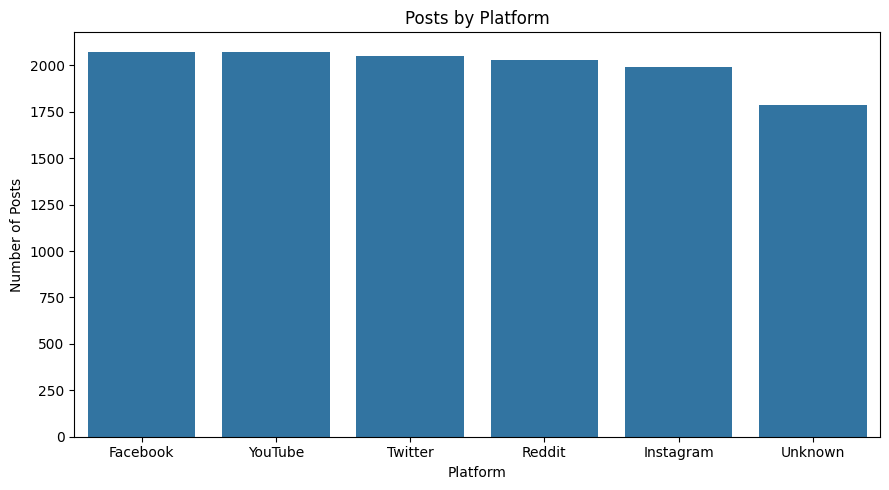

In [70]:
plt.figure(figsize=(9, 5))

sns.barplot(
    data=platform_counts,
    x="Platform",
    y="Post Count"
)

plt.title("Posts by Platform")
plt.xlabel("Platform")
plt.ylabel("Number of Posts")

plt.tight_layout()
plt.show()

In [71]:
platform_share = (
    posts["platform"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
    .reset_index()
)

platform_share.columns = ["Platform", "Percentage"]

platform_share

,Platform,Percentage
0,Facebook,17.28
1,YouTube,17.27
2,Twitter,17.08
3,Reddit,16.92
4,Instagram,16.58
5,Unknown,14.87


In [72]:
posts_per_user = (
    posts.groupby("user_id")
    .size()
    .reset_index(name="post_count")
)

posts_per_user.head()

,user_id,post_count
0,user_00evmn72,11
1,user_01hav2yk,8
2,user_01mu2x1s,9
3,user_0281t7ll,12
4,user_02sm9ly7,8


In [73]:
posts_per_user["post_count"].describe()

,post_count
count,1500.000000
mean,8.000000
std,2.851214
min,1.000000
25%,6.000000
50%,8.000000
75%,10.000000
max,22.000000


In [74]:
posts_per_user.sort_values(
    "post_count",
    ascending=False
).head(10)

,user_id,post_count
1487,user_zqv2vrf5,22
943,user_nfo3ih5u,19
925,user_n0ok02rt,18
1060,user_q3vs0uj7,18
377,user_8wk0j5ae,18
19,user_0irp4abu,17
730,user_i1e1kek5,16
1229,user_uerv85na,16
1377,user_xetn4exw,16
1235,user_ujllj1n7,16


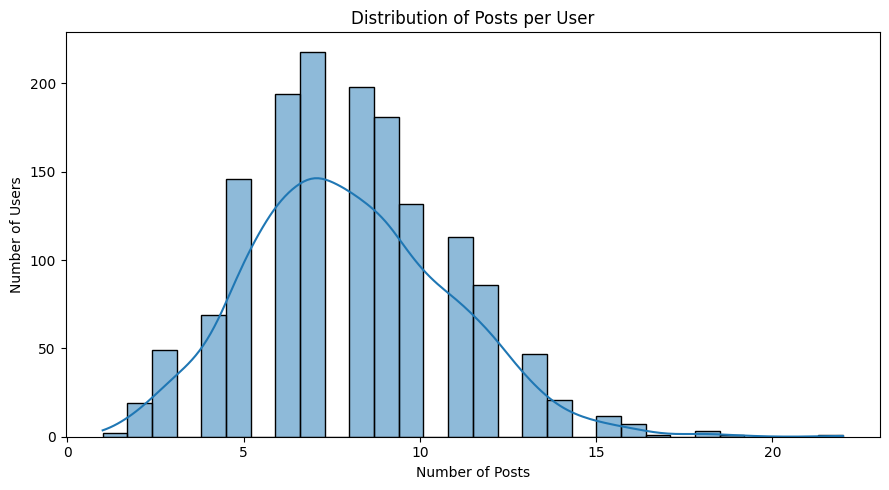

In [75]:
plt.figure(figsize=(9, 5))

sns.histplot(
    posts_per_user["post_count"],
    bins=30,
    kde=True
)

plt.title("Distribution of Posts per User")
plt.xlabel("Number of Posts")
plt.ylabel("Number of Users")

plt.tight_layout()
plt.show()

## 2. Engagement Analysis

Engagement is measured using likes, shares, and comments. This section examines the distribution of engagement across posts and platforms and identifies patterns and potential outliers.

The analysis focuses on both aggregate engagement and the relative behavior of different platforms.

In [77]:
engagement_cols = ["likes", "shares", "comments"]

posts[engagement_cols].describe().T

,count,mean,std,min,25%,50%,75%,max
likes,12000.0,2497.174833,1291.980071,0.0,1547.0,2503.0,3450.0,5000.0
shares,12000.0,1007.167167,575.072282,0.0,510.0,1018.0,1501.0,2000.0
comments,12000.0,504.345750,288.684160,0.0,253.0,503.0,755.0,1000.0


In [78]:
posts["total_engagement"] = (
    posts["likes"] +
    posts["shares"] +
    posts["comments"]
)

In [79]:
posts["total_engagement"].describe()

,total_engagement
count,12000.000000
mean,4008.687750
std,1447.835043
min,153.000000
25%,2990.750000
50%,4012.000000
75%,5019.000000
max,7893.000000


In [80]:
posts["total_engagement"].sort_values(
    ascending=False
).head(10)

,total_engagement
12227,7893.0
3675,7793.0
10583,7764.0
3350,7755.0
8889,7738.0
8578,7723.0
5201,7712.0
6738,7683.0
8934,7628.0
6646,7610.0


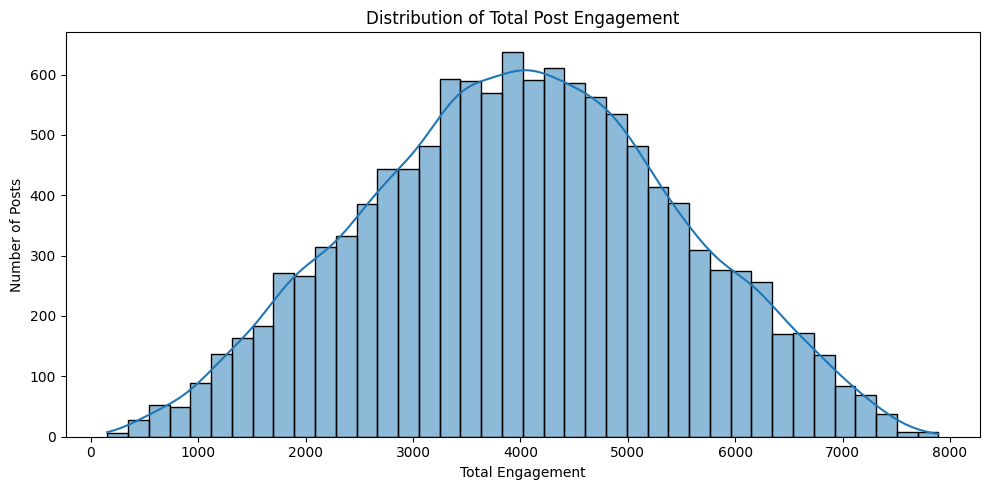

In [81]:
plt.figure(figsize=(10, 5))

sns.histplot(
    posts["total_engagement"],
    bins=40,
    kde=True
)

plt.title("Distribution of Total Post Engagement")
plt.xlabel("Total Engagement")
plt.ylabel("Number of Posts")

plt.tight_layout()
plt.show()

In [82]:
platform_engagement = (
    posts.groupby("platform")[engagement_cols]
    .mean()
    .round(2)
)

platform_engagement

,likes,shares,comments
platform,,,
Facebook,2534.89,984.17,506.94
Instagram,2496.19,1040.84,499.80
Reddit,2489.65,1002.23,511.18
Twitter,2437.86,1005.39,506.13
Unknown,2472.08,998.61,496.54
YouTube,2548.00,1011.83,504.38


In [83]:
platform_engagement["total_engagement"] = (
    platform_engagement["likes"] +
    platform_engagement["shares"] +
    platform_engagement["comments"]
)

platform_engagement.sort_values(
    "total_engagement",
    ascending=False
)

,likes,shares,comments,total_engagement
platform,,,,
YouTube,2548.00,1011.83,504.38,4064.21
Instagram,2496.19,1040.84,499.80,4036.83
Facebook,2534.89,984.17,506.94,4026.00
Reddit,2489.65,1002.23,511.18,4003.06
Unknown,2472.08,998.61,496.54,3967.23
Twitter,2437.86,1005.39,506.13,3949.38


In [84]:
platform_median = (
    posts.groupby("platform")[engagement_cols]
    .median()
    .round(2)
)

platform_median["total_engagement"] = (
    platform_median["likes"] +
    platform_median["shares"] +
    platform_median["comments"]
)

platform_median.sort_values(
    "total_engagement",
    ascending=False
)

,likes,shares,comments,total_engagement
platform,,,,
YouTube,2628.0,1017.0,498.0,4143.0
Facebook,2571.0,993.5,504.0,4068.5
Instagram,2503.0,1049.0,498.0,4050.0
Reddit,2498.0,1016.0,513.0,4027.0
Twitter,2430.0,1022.0,504.0,3956.0
Unknown,2436.0,1005.5,498.5,3940.0


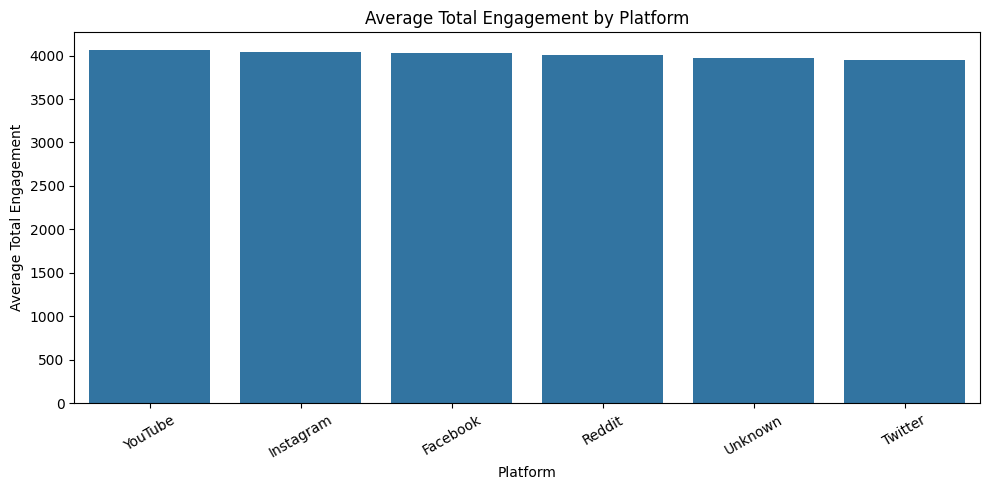

In [85]:
platform_total = (
    posts.groupby("platform")["total_engagement"]
    .mean()
    .sort_values(ascending=False)
    .reset_index()
)

plt.figure(figsize=(10, 5))

sns.barplot(
    data=platform_total,
    x="platform",
    y="total_engagement"
)

plt.title("Average Total Engagement by Platform")
plt.xlabel("Platform")
plt.ylabel("Average Total Engagement")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [86]:
engagement_corr = posts[
    ["likes", "shares", "comments"]
].corr()

engagement_corr

,likes,shares,comments
likes,1.000000,-0.002868,0.012232
shares,-0.002868,1.000000,0.024406
comments,0.012232,0.024406,1.000000


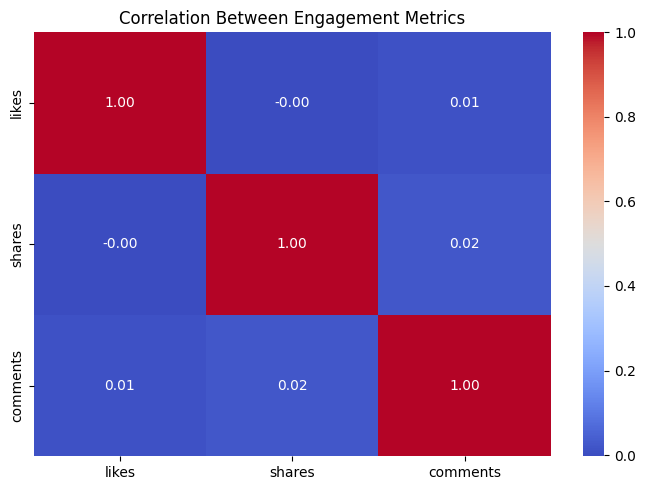

In [87]:
plt.figure(figsize=(7, 5))

sns.heatmap(
    engagement_corr,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Between Engagement Metrics")

plt.tight_layout()
plt.show()

In [88]:
top_posts = (
    posts[
        [
            "post_id",
            "platform",
            "likes",
            "shares",
            "comments",
            "total_engagement"
        ]
    ]
    .sort_values(
        "total_engagement",
        ascending=False
    )
    .head(10)
)

top_posts

,post_id,platform,likes,shares,comments,total_engagement
12227,ycjj5zzt7mvx,Instagram,4983.0,1919,991,7893.0
3675,wo7py9aljg3t,Reddit,4864.0,1981,948,7793.0
10583,gmoeib832zbs,Facebook,4902.0,1880,982,7764.0
3350,5kvuyvf38nqx,YouTube,4923.0,1971,861,7755.0
8889,pvfl3d8hj7jd,Instagram,4989.0,1840,909,7738.0
8578,tdgjjylpua20,Unknown,4979.0,1932,812,7723.0
5201,tne7s3o4l4wd,Instagram,4931.0,1903,878,7712.0
6738,a1kiwl618kzy,Facebook,4811.0,1952,920,7683.0
8934,fp89q1ickn9w,Twitter,4740.0,1933,955,7628.0
6646,5n161ir5hhhr,YouTube,4751.0,1981,878,7610.0


In [89]:
posts.drop(
    columns=["total_engagement"],
    inplace=True
)

In [90]:
posts.reset_index(drop=True, inplace=True)

In [91]:
# Posts per month

monthly_posts = (
    posts
    .set_index("timestamp")
    .resample("ME")
    .size()
    .reset_index(name="post_count")
)

monthly_posts

,timestamp,post_count
0,2024-05-31,1038
1,2024-06-30,979
2,2024-07-31,996
3,2024-08-31,1015
4,2024-09-30,974
5,2024-10-31,1029
6,2024-11-30,1025
7,2024-12-31,1035
8,2025-01-31,1007
9,2025-02-28,914


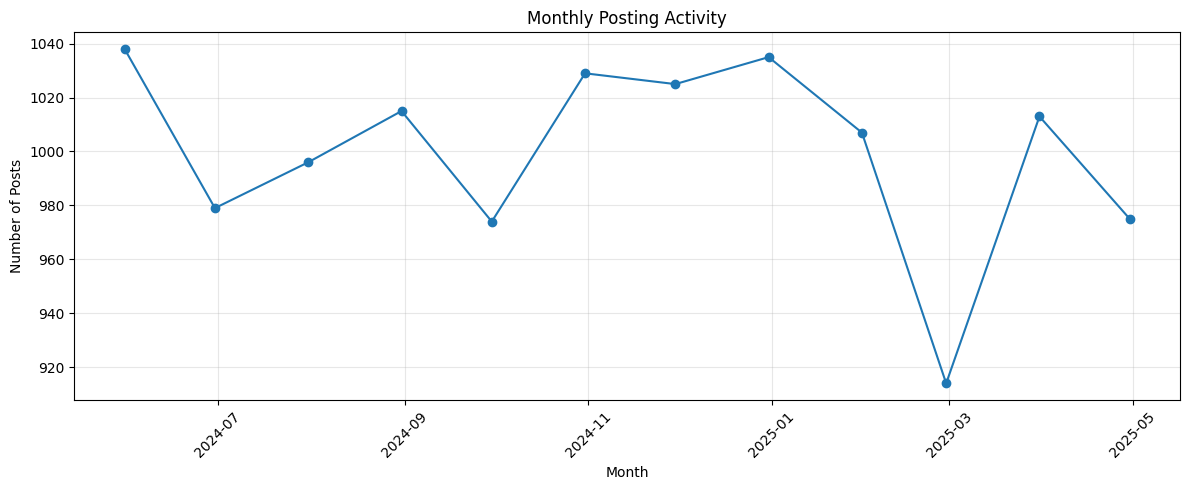

In [92]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_posts["timestamp"],
    monthly_posts["post_count"],
    marker="o"
)

plt.title("Monthly Posting Activity")
plt.xlabel("Month")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [93]:
# Posts by day of week

posts_by_day = (
    posts
    .assign(day_of_week=posts["timestamp"].dt.day_name())
    .groupby("day_of_week")
    .size()
    .reindex([
        "Monday",
        "Tuesday",
        "Wednesday",
        "Thursday",
        "Friday",
        "Saturday",
        "Sunday"
    ])
    .reset_index(name="post_count")
)

posts_by_day

,day_of_week,post_count
0,Monday,1720
1,Tuesday,1677
2,Wednesday,1771
3,Thursday,1718
4,Friday,1723
5,Saturday,1675
6,Sunday,1716


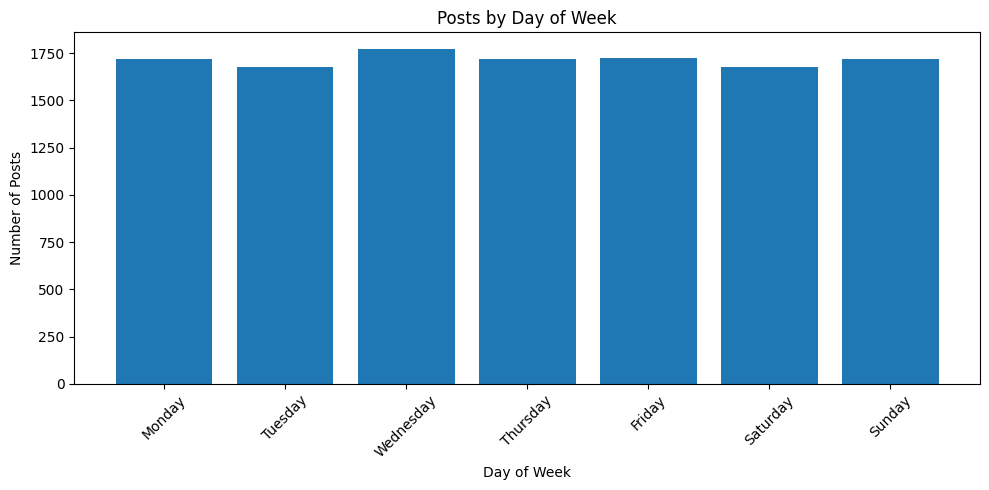

In [94]:
plt.figure(figsize=(10, 5))

plt.bar(
    posts_by_day["day_of_week"],
    posts_by_day["post_count"]
)

plt.title("Posts by Day of Week")
plt.xlabel("Day of Week")
plt.ylabel("Number of Posts")
plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [95]:
# Posts by hour of day

posts_by_hour = (
    posts
    .assign(hour=posts["timestamp"].dt.hour)
    .groupby("hour")
    .size()
    .reset_index(name="post_count")
)

posts_by_hour

,hour,post_count
0,0,3902
1,1,362
2,2,357
3,3,384
4,4,342
5,5,329
6,6,344
7,7,340
8,8,346
9,9,357


In [96]:
# Check the distribution of minutes and seconds for posts at midnight

midnight_posts = posts[posts["timestamp"].dt.hour == 0]

print("Midnight posts:", len(midnight_posts))
print()
print("Minute distribution:")
print(midnight_posts["timestamp"].dt.minute.value_counts().head(10))
print()
print("Second distribution:")
print(midnight_posts["timestamp"].dt.second.value_counts().head(10))

Midnight posts: 3902

Minute distribution:
timestamp
0     3529
5       12
29      11
34      11
16      11
2       10
25      10
47       9
35       9
40       9
Name: count, dtype: int64

Second distribution:
timestamp
0     3534
9       10
54      10
20       9
51       9
30       9
18       9
34       9
6        9
7        8
Name: count, dtype: int64


In [98]:
# Monthly average engagement

monthly_engagement = (
    posts
    .set_index("timestamp")
    .resample("ME")["likes", "shares", "comments"]
    .mean()
    .reset_index()
)

monthly_engagement.round(2)

,timestamp,likes,shares,comments
0,2024-05-31,2466.80,992.53,510.56
1,2024-06-30,2430.97,998.87,504.01
2,2024-07-31,2465.35,1025.69,485.13
3,2024-08-31,2570.34,1019.43,494.40
4,2024-09-30,2532.06,1002.43,492.42
5,2024-10-31,2542.29,1004.93,511.66
6,2024-11-30,2512.59,1000.55,514.73
7,2024-12-31,2513.07,1039.64,504.36
8,2025-01-31,2430.45,997.88,499.66
9,2025-02-28,2462.95,999.89,510.42


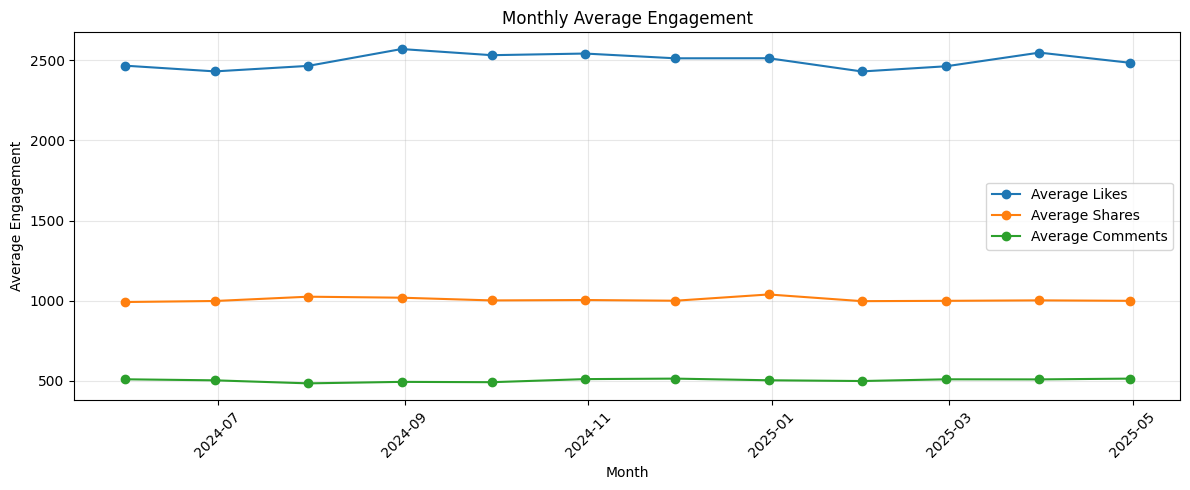

In [99]:
plt.figure(figsize=(12, 5))

plt.plot(
    monthly_engagement["timestamp"],
    monthly_engagement["likes"],
    marker="o",
    label="Average Likes"
)

plt.plot(
    monthly_engagement["timestamp"],
    monthly_engagement["shares"],
    marker="o",
    label="Average Shares"
)

plt.plot(
    monthly_engagement["timestamp"],
    monthly_engagement["comments"],
    marker="o",
    label="Average Comments"
)

plt.title("Monthly Average Engagement")
plt.xlabel("Month")
plt.ylabel("Average Engagement")
plt.xticks(rotation=45)
plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

Content Analysis


In [100]:
# Calculate text length

posts["text_length"] = posts["text_content"].str.len()

print("Text Length Statistics")
print("-" * 30)
print(posts["text_length"].describe().round(2))

Text Length Statistics
------------------------------
count    12000.00
mean       102.44
std         39.80
min          5.00
25%         99.00
50%        114.00
75%        127.00
max        172.00
Name: text_length, dtype: float64


In [101]:
# Check the shortest and longest posts

print("Shortest posts:")
print(posts[["post_id", "text_content", "text_length"]]
      .sort_values("text_length")
      .head(10))

print("\nLongest posts:")
print(posts[["post_id", "text_content", "text_length"]]
      .sort_values("text_length", ascending=False)
      .head(10))

Shortest posts:
            post_id text_content  text_length
7290   y41xyag3itms        NULLé            5
2299   j0nr906xh7m2        NULL&            5
9588   yom8y639g4qd        NULLé            5
1856   ogr9yk4ff2d5        NULLé            5
3356   6vytwg81jbtj        NULL&            5
10074  vt4ejhf73fe3        NULL&            5
10081  yypyqbzpjtpa        NULL&            5
1557   65gsj2nqid6j        NULL&            5
9000   6nj3dn1v155x        NULLé            5
4049   dsx8bppwalr5        NULL&            5

Longest posts:
            post_id                                       text_content  \
7497   71fsu4kc5u4j  Has anyone else experienced customer service w...   
10525  irtqllk9k6ow  Has anyone else experienced connectivity issue...   
17     9nrn7caujskm  Has anyone else experienced connectivity issue...   
2087   b4xe94508f4n  Comparing Microsoft Surface Laptop to the comp...   
273    849vopmpaov5  What's your opinion about Coca-Cola's Coca-Col...   
3384   pf7i02munpp

In [102]:
def clean_text(text):
    if pd.isna(text):
        return "[MISSING_TEXT]"

    text = str(text).strip()

    # Remove HTML tags
    text = re.sub(
        r"<[^>]+>",
        "",
        text
    )

    # Decode HTML entities
    text = html.unescape(text)

    # Repair observed UTF-8 mojibake
    if "Ã" in text:
        try:
            text = text.encode("latin1").decode("utf-8")
        except (UnicodeEncodeError, UnicodeDecodeError):
            pass

    # Treat NULL variants / empty text as missing
    if re.fullmatch(r"NULL[^A-Za-z0-9]*", text, flags=re.IGNORECASE):
        return "[MISSING_TEXT]"

    if text.strip() == "":
        return "[MISSING_TEXT]"

    return text.strip()

In [103]:
posts["text_content"] = (
    posts["text_content"]
    .apply(clean_text)
)

In [104]:
posts["text_content"].value_counts().head(10)

,count
text_content,
[MISSING_TEXT],1779
Just tried the Pepsi Zero Sugar from Pepsi. Wouldn't recommend. #Premium Curious about your experience too.,2
Loving it with my new Pepsi Zero Sugar from Pepsi! Exceeded my expectations. #Quality Curious about your experience too.,2
"Just saw an ad for Adidas Samba during the GlobalCampaign. Worth every penny. #Fashion, #Premium, #BestValue",1
Comparing Samsung Galaxy Tab to the competition. Returning it ASAP. #Limited Would love to get your feedback!,1
Comparing Amazon Eero WiFi to the competition. Highly recommend. #Fashion Would love to get your feedback!,1
"Has anyone else experienced software bugs with Adidas's Gazelle? Had issues with it. #Quality, #Health",1
"Amazon HolidaySpecial is disappointing! Can't wait to see what's coming next. #Fitness, #Limited, #Discount Really interested in hearing your thoughts!",1
"Feeling let down with my new Surface Pro from Microsoft! Had issues with it. #Affordable, #Food",1


In [105]:
print("Remaining NULL-like texts:",
      posts["text_content"].str.contains(
          r"^NULL",
          case=False,
          na=False
      ).sum())

Remaining NULL-like texts: 0


In [106]:
# Text length for valid post content only

valid_text = posts[
    posts["text_content"] != "[MISSING_TEXT]"
].copy()

valid_text["text_length"] = valid_text["text_content"].str.len()

print("Valid text posts:", len(valid_text))
print()
print(valid_text["text_length"].describe().round(2))

Valid text posts: 10221

count    10221.00
mean       117.87
std         15.92
min         68.00
25%        107.00
50%        118.00
75%        129.00
max        172.00
Name: text_length, dtype: float64


In [107]:
# Text length categories

text_length_summary = pd.cut(
    valid_text["text_length"],
    bins=[0, 50, 100, 150, 200, float("inf")],
    labels=[
        "0–50",
        "51–100",
        "101–150",
        "151–200",
        "200+"
    ]
).value_counts().sort_index()

text_length_summary

,count
text_length,
0–50,0
51–100,1516
101–150,8497
151–200,208
200+,0


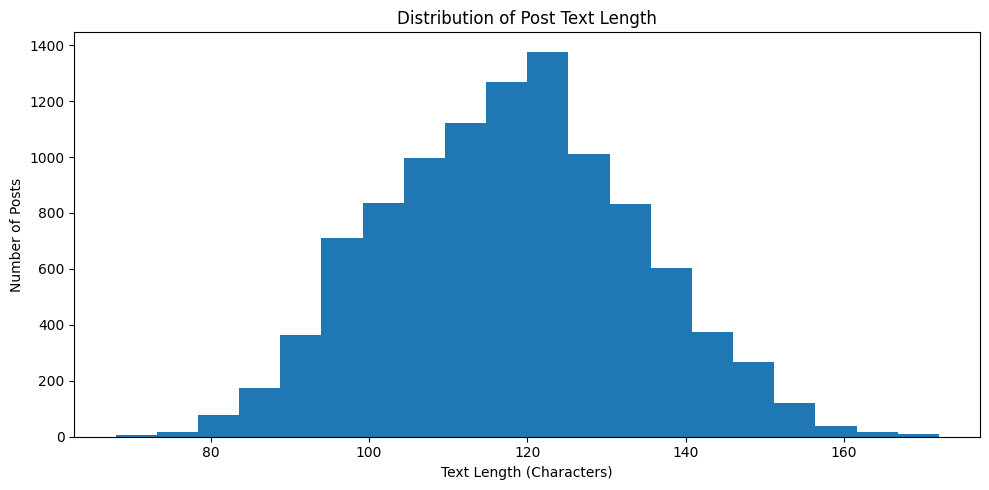

In [108]:
plt.figure(figsize=(10, 5))

plt.hist(
    valid_text["text_length"],
    bins=20
)

plt.title("Distribution of Post Text Length")
plt.xlabel("Text Length (Characters)")
plt.ylabel("Number of Posts")

plt.tight_layout()
plt.show()

In [109]:
# Relationship between text length and engagement

content_engagement = valid_text[
    ["text_length", "likes", "shares", "comments"]
].copy()

content_engagement.corr().round(3)

,text_length,likes,shares,comments
text_length,1.000,-0.008,-0.028,-0.015
likes,-0.008,1.000,-0.003,0.014
shares,-0.028,-0.003,1.000,0.025
comments,-0.015,0.014,0.025,1.000


In [110]:
# Content feature counts

valid_text["hashtag_count"] = (
    valid_text["text_content"]
    .str.count(r"#\w+")
)

valid_text["mention_count"] = (
    valid_text["text_content"]
    .str.count(r"@\w+")
)

content_features = pd.DataFrame({
    "Feature": [
        "Posts with hashtags",
        "Posts with mentions",
        "Posts without hashtags",
        "Posts without mentions"
    ],
    "Count": [
        (valid_text["hashtag_count"] > 0).sum(),
        (valid_text["mention_count"] > 0).sum(),
        (valid_text["hashtag_count"] == 0).sum(),
        (valid_text["mention_count"] == 0).sum()
    ]
})

content_features["Percentage"] = (
    content_features["Count"] / len(valid_text) * 100
).round(2)

content_features

,Feature,Count,Percentage
0,Posts with hashtags,10221,100.00
1,Posts with mentions,1376,13.46
2,Posts without hashtags,0,0.00
3,Posts without mentions,8845,86.54


In [111]:
# Number of hashtags per post

hashtag_distribution = (
    valid_text["hashtag_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

hashtag_distribution.columns = [
    "Hashtag Count",
    "Post Count"
]

hashtag_distribution

,Hashtag Count,Post Count
0,1,3358
1,2,3416
2,3,3447


In [112]:
# Number of mentions per post

mention_distribution = (
    valid_text["mention_count"]
    .value_counts()
    .sort_index()
    .reset_index()
)

mention_distribution.columns = [
    "Mention Count",
    "Post Count"
]

mention_distribution

,Mention Count,Post Count
0,0,8845
1,1,679
2,2,697


In [113]:
# Compare engagement for posts with and without mentions

valid_text["has_mention"] = valid_text["mention_count"] > 0

mention_engagement = (
    valid_text
    .groupby("has_mention")[["likes", "shares", "comments"]]
    .agg(["mean", "median"])
    .round(2)
)

mention_engagement

likes           shares         comments       
                mean  median     mean  median     mean median
has_mention                                                  
False        2504.53  2503.0  1004.21  1012.0   502.62  500.0
True         2417.35  2498.0  1009.82  1035.0   515.37  525.0

In [114]:
from collections import Counter
import re

# Combine all valid post text
all_text = " ".join(valid_text["text_content"].astype(str))

# Extract words
words = re.findall(r"\b[a-zA-Z]{3,}\b", all_text.lower())

# Common English stopwords
stopwords = {
    "the", "and", "for", "with", "that", "this", "from",
    "have", "your", "about", "would", "what", "just",
    "new", "not", "but", "are", "was", "has", "had",
    "its", "they", "you", "our", "their", "too", "can",
    "all", "get", "out", "one", "very", "more", "my",
    "like", "how", "any", "who", "been", "when", "did",
    "into", "than", "really", "with", "would"
}

word_counts = Counter(
    word for word in words
    if word not in stopwords
)

word_counts.most_common(20)

[('let', 1988),
 ('love', 1880),
 ('feedback', 1880),
 ('know', 1853),
 ('think', 1853),
 ('pepsi', 1841),
 ('curious', 1824),
 ('experience', 1824),
 ('interested', 1797),
 ('hearing', 1797),
 ('thoughts', 1797),
 ('quality', 1401),
 ('worth', 1332),
 ('recommend', 1280),
 ('coca', 1265),
 ('cola', 1265),
 ('anyone', 1216),
 ('apple', 1133),
 ('adidas', 1070),
 ('review', 1053)]

User/Follower Analysis


In [115]:
# Posts per user

posts_per_user = (
    posts
    .groupby("user_id")
    .size()
    .reset_index(name="post_count")
)

print("Posts per user statistics")
print("-" * 30)
print(posts_per_user["post_count"].describe().round(2))

Posts per user statistics
------------------------------
count    1500.00
mean        8.00
std         2.85
min         1.00
25%         6.00
50%         8.00
75%        10.00
max        22.00
Name: post_count, dtype: float64


In [116]:
# Most active users

posts_per_user.sort_values(
    "post_count",
    ascending=False
).head(10)

,user_id,post_count
1487,user_zqv2vrf5,22
943,user_nfo3ih5u,19
925,user_n0ok02rt,18
1060,user_q3vs0uj7,18
377,user_8wk0j5ae,18
19,user_0irp4abu,17
730,user_i1e1kek5,16
1229,user_uerv85na,16
1377,user_xetn4exw,16
1235,user_ujllj1n7,16


In [117]:
# Follower count statistics

print("Follower Count Statistics")
print("-" * 30)
print(users["follower_count"].describe().round(2))

Follower Count Statistics
------------------------------
count     1500.00
mean     24964.02
std      14185.48
min        109.00
25%      12771.75
50%      24741.50
75%      37097.25
max      49944.00
Name: follower_count, dtype: float64


In [118]:
# Users with the highest follower counts

users[
    ["user_id", "follower_count"]
].sort_values(
    "follower_count",
    ascending=False
).head(10)

,user_id,follower_count
737,user_3o7w66o2,49944
910,user_u98jwp3f,49936
1417,user_usts5yuo,49933
850,user_d4eat3v3,49914
57,user_siuvpkza,49905
947,user_ujllj1n7,49855
803,user_kr0ydzhh,49836
302,user_9asov0m8,49763
326,user_84k7x6zn,49736
1370,user_t028mbub,49727


In [119]:
# Merge follower count with post data

posts_with_followers = posts.merge(
    users[["user_id", "follower_count"]],
    on="user_id",
    how="left"
)

print("Posts:", len(posts_with_followers))
print("Missing follower counts:",
      posts_with_followers["follower_count"].isna().sum())

Posts: 12000
Missing follower counts: 0


In [120]:
# Correlation between followers and engagement

follower_engagement_corr = (
    posts_with_followers[
        ["follower_count", "likes", "shares", "comments"]
    ]
    .corr()
    .round(3)
)

follower_engagement_corr

,follower_count,likes,shares,comments
follower_count,1.000,0.008,-0.014,-0.000
likes,0.008,1.000,-0.003,0.012
shares,-0.014,-0.003,1.000,0.024
comments,-0.000,0.012,0.024,1.000


In [121]:
# User-level activity and follower summary

user_activity = (
    posts.groupby("user_id")
    .size()
    .reset_index(name="post_count")
)

user_summary = user_activity.merge(
    users[["user_id", "follower_count"]],
    on="user_id",
    how="left"
)

user_summary[
    ["post_count", "follower_count"]
].corr().round(3)

,post_count,follower_count
post_count,1.000,-0.008
follower_count,-0.008,1.000


In [122]:
# Divide users into follower groups

user_summary["follower_group"] = pd.qcut(
    user_summary["follower_count"],
    q=4,
    labels=[
        "Lowest 25%",
        "25–50%",
        "50–75%",
        "Highest 25%"
    ]
)

user_summary.groupby("follower_group")[
    ["follower_count", "post_count"]
].mean().round(2)

/tmp/ipykernel_4691/4058405872.py:14: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_summary.groupby("follower_group")[


,follower_count,post_count
follower_group,,
Lowest 25%,6658.28,8.12
25–50%,18718.30,7.87
50–75%,31050.34,8.09
Highest 25%,43429.15,7.93


Anomaly Analysis.


In [123]:
# Check for outliers using the IQR method

engagement_cols = ["likes", "shares", "comments"]

for col in engagement_cols:
    Q1 = posts[col].quantile(0.25)
    Q3 = posts[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outliers = posts[
        (posts[col] < lower_bound) |
        (posts[col] > upper_bound)
    ]

    print(f"\n{col.upper()}")
    print(f"Q1: {Q1:.2f}")
    print(f"Q3: {Q3:.2f}")
    print(f"IQR: {IQR:.2f}")
    print(f"Lower bound: {lower_bound:.2f}")
    print(f"Upper bound: {upper_bound:.2f}")
    print(f"Outlier count: {len(outliers)}")


LIKES
Q1: 1547.00
Q3: 3450.00
IQR: 1903.00
Lower bound: -1307.50
Upper bound: 6304.50
Outlier count: 0

SHARES
Q1: 510.00
Q3: 1501.00
IQR: 991.00
Lower bound: -976.50
Upper bound: 2987.50
Outlier count: 0

COMMENTS
Q1: 253.00
Q3: 755.00
IQR: 502.00
Lower bound: -500.00
Upper bound: 1508.00
Outlier count: 0


In [124]:
# Check zero engagement values

for col in ["likes", "shares", "comments"]:
    zero_count = (posts[col] == 0).sum()
    zero_pct = zero_count / len(posts) * 100

    print(f"{col}: {zero_count} zero values ({zero_pct:.2f}%)")

likes: 1 zero values (0.01%)
shares: 5 zero values (0.04%)
comments: 13 zero values (0.11%)


In [125]:
# Check whether engagement metrics contain suspicious relationships

print("Shares greater than likes:", (posts["shares"] > posts["likes"]).sum())
print("Comments greater than likes:", (posts["comments"] > posts["likes"]).sum())
print("Comments greater than shares:", (posts["comments"] > posts["shares"]).sum())

Shares greater than likes: 1987
Comments greater than likes: 971
Comments greater than shares: 2943


In [126]:
# Final validation of engagement values

print("Negative likes:", (posts["likes"] < 0).sum())
print("Negative shares:", (posts["shares"] < 0).sum())
print("Negative comments:", (posts["comments"] < 0).sum())
print("Missing likes:", posts["likes"].isna().sum())
print("Missing shares:", posts["shares"].isna().sum())
print("Missing comments:", posts["comments"].isna().sum())

Negative likes: 0
Negative shares: 0
Negative comments: 0
Missing likes: 0
Missing shares: 0
Missing comments: 0


In [127]:
# Check for duplicate post IDs after cleaning

print("Duplicate post_ids:", posts["post_id"].duplicated().sum())
print("Total posts:", len(posts))
print("Unique post_ids:", posts["post_id"].nunique())


Duplicate post_ids: 0
Total posts: 12000
Unique post_ids: 12000


In [128]:
print("Missing timestamps:", posts["timestamp"].isna().sum())
print("Earliest timestamp:", posts["timestamp"].min())
print("Latest timestamp:", posts["timestamp"].max())

Missing timestamps: 0
Earliest timestamp: 2024-05-01 00:00:00
Latest timestamp: 2025-04-30 21:57:10


In [129]:
# Check that every post references an existing user

invalid_users = ~posts["user_id"].isin(users["user_id"])

print("Posts with invalid user_id:", invalid_users.sum())
print("Total posts:", len(posts))

Posts with invalid user_id: 0
Total posts: 12000


## Key Insights & Conclusions

### 1. Data Quality
- The corrupted dataset contained duplicate posts, missing platform/text/likes values, negative likes, inconsistent timestamps, and text encoding/HTML corruption.
- After preprocessing, the dataset contains 12,000 unique posts with no missing engagement or timestamp values and no negative engagement values.
- All post `user_id` values successfully match the Users dataset.

### 2. Engagement
- Engagement is dominated by likes, followed by shares and comments.
- No statistical outliers were detected in likes, shares, or comments using the IQR method.
- Zero-engagement values are extremely rare and were retained as valid observations.

### 3. Temporal Patterns
- Monthly posting activity remained relatively stable throughout the May 2024–April 2025 period.
- May 2024 had the highest number of posts (1,038), while February 2025 had the lowest (914).
- Posting activity was broadly distributed across days of the week, with Wednesday having the highest count and Saturday the lowest.
- Average monthly engagement showed moderate fluctuations but no sustained upward or downward trend.
- Hour-of-day analysis was not used for behavioral interpretation because date-only timestamps in the source data were normalized to midnight.

### 4. Content Patterns
- Among posts with valid text, the average text length was approximately 118 characters.
- Most valid posts (83.1%) contained between 101 and 150 characters.
- Text length showed almost no linear relationship with likes, shares, or comments.
- Hashtags were present across all valid-text posts, with 1–3 hashtags occurring in nearly equal proportions.
- Approximately 13.5% of valid-text posts contained mentions.
- Mentioned posts showed only small differences in average engagement compared with posts without mentions.

### 5. User and Follower Patterns
- Users published an average of 8 posts, with a median of 8 posts per user.
- Posting activity was broadly distributed rather than concentrated among a small number of users.
- Follower counts ranged from 109 to 49,944.
- Follower count showed almost no linear relationship with likes, shares, or comments.
- Posting frequency and follower count also showed almost no relationship (correlation = -0.008).
- Average posting frequency remained almost identical across follower-count quartiles.

### 6. Overall Conclusion
- The cleaned dataset is internally consistent and suitable for downstream analysis.
- Social activity is relatively stable over time, with limited evidence of strong temporal or content-driven engagement effects.
- Follower size and posting frequency do not appear to be strong linear predictors of engagement in this dataset.
- The strongest value of the analysis comes from recovering the corrupted data while preserving legitimate observations and establishing a reliable, validated dataset for further analysis.


In [131]:

# Remove temporary EDA column
posts = posts.drop(columns=["text_length"])

print("Posts shape:", posts.shape)
print("Posts columns:", posts.columns.tolist())

Posts shape: (12000, 8)
Posts columns: ['post_id', 'user_id', 'platform', 'text_content', 'timestamp', 'likes', 'shares', 'comments']


In [132]:
print("Posts shape:", posts.shape)
print("\nPosts columns:")
print(posts.columns.tolist())

print("\nUsers shape:", users.shape)
print("\nUsers columns:")
print(users.columns.tolist())

Posts shape: (12000, 8)

Posts columns:
['post_id', 'user_id', 'platform', 'text_content', 'timestamp', 'likes', 'shares', 'comments']

Users shape: (1500, 5)

Users columns:
['user_id', 'location', 'language', 'account_created', 'follower_count']


In [133]:
print("Missing values:")
print(posts.isna().sum())

print("\nDuplicate post IDs:", posts["post_id"].duplicated().sum())

print("\nNegative engagement values:")
print("Likes:", (posts["likes"] < 0).sum())
print("Shares:", (posts["shares"] < 0).sum())
print("Comments:", (posts["comments"] < 0).sum())

print("\nFinal shapes:")
print("Posts:", posts.shape)
print("Users:", users.shape)

Missing values:
post_id         0
user_id         0
platform        0
text_content    0
timestamp       0
likes           0
shares          0
comments        0
dtype: int64

Duplicate post IDs: 0

Negative engagement values:
Likes: 0
Shares: 0
Comments: 0

Final shapes:
Posts: (12000, 8)
Users: (1500, 5)


In [134]:
# Export cleaned datasets

posts.to_csv("Social_Engine_Posts_Cleaned.csv", index=False)
users.to_csv("Social_Engine_Users_Cleaned.csv", index=False)

print("Cleaned datasets exported successfully.")


Cleaned datasets exported successfully.
